# Check whether the model is working

**NOTES:**
- The model needs finetuning before being evaluated.
- Currently only numerical features can be used


In [1]:
import sys
sys.path.append("../")
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from mlresearch.datasets import BinaryDatasets
from explainerpfn.base import SingleFeatureExplainerPFN, ExplainerPFN

# just a simple toy dataset (all continuous features)

datasets = BinaryDatasets(names=["BANKNOTE AUTHENTICATION"]).download()
df = datasets["BANKNOTE AUTHENTICATION"]

df_train_rf = df.sample(500, replace=False, random_state=42)
df_train = df.drop(df_train_rf.index).sample(500, replace=False, random_state=42)
df_test = df.drop(df_train_rf.index).drop(df_train.index)

# preprocess data (standardscaler)
scaler = StandardScaler().fit(df_train_rf.loc[:, df_train_rf.columns.drop("target")].values)

Xy = []
for df_ in [df_train_rf, df_train, df_test]:
    df_ = df_.reset_index(drop=True)
    df_.loc[:, df_.columns.drop("target")] = scaler.transform(df_.loc[:, df_.columns.drop("target")].values)
    X = df_.loc[:, df_.columns.drop("target")].values
    y = df_["target"].values
    Xy.append((X, y))

(X_train_rf, y_train_rf), (X_train, _), (X_test, _) = Xy

Datasets:   0%|          | 0/1 [00:00<?, ?it/s]

# Get a classifier, predictions and SHAP explanations

In [2]:
clf = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
clf.fit(X_train_rf, y_train_rf)

y_train = clf.predict_proba(X_train)[:, 1]
y_test = clf.predict_proba(X_test)[:, 1]

In [3]:
def get_shap_values(X, model, masker=None):
    """
    Get SHAP values for the given model and data.
    """
    xai = shap.Explainer(
        model=model, 
        masker=masker
    )

    shap_explanation_train = xai(X).values[:, :, -1]

    return shap_explanation_train

In [4]:
all_shap_values = []
for X, y in tqdm(list(zip([X_train, X_test], [y_train, y_test])), desc="Calculating SHAP values"):
    X_shap = get_shap_values(X, clf, masker=X_train)
    df_shap = pd.DataFrame(X_shap.astype(float), columns=df_train.columns.drop("target"))
    df_shap["target"] = y
    all_shap_values.append((X_shap, df_shap))
    
(X_train_shap, df_shap_train), (X_test_shap, df_shap_test) = all_shap_values

Calculating SHAP values:   0%|          | 0/2 [00:00<?, ?it/s]

 97%|=================== | 725/744 [00:11<00:00]        

# PFN Explanations - Single feature

In [5]:
self = SingleFeatureExplainerPFN(feature_idx=1, random_state=42)
self.fit(X_train, y_train)

# averaged_logits, outputs, borders = self.forward(X, np.zeros_like(y), 0)
output = self.predict(X_test, y_test)

# Generate explanations for the entire dataset

In [6]:
explanations = np.zeros_like(X_test, dtype=float)
for i in tqdm(range(X_test.shape[1])):
    singlepfn = SingleFeatureExplainerPFN(feature_idx=i, softmax_temperature=0.9, random_state=42)
    singlepfn.fit(X_train, y_train)
    explanations[:, i] = singlepfn.predict(X_test, y_test)

  0%|          | 0/4 [00:00<?, ?it/s]

In [7]:
# Apply correction to ensure additivity
base_value = np.mean(y_train)
error = (y_test - (explanations.sum(axis=1) + base_value))
error = np.repeat(error.reshape(-1, 1), repeats=explanations.shape[1], axis=1) / explanations.shape[1]
explanations_corrected = explanations + error

In [8]:
correlations = {}

# Correlation between input values and the predicted target
correlations["input_values"] = df.corr()["target"]

# Correlation between PFN explanations and the predicted target
df_explanations = pd.DataFrame(explanations.astype(float), columns=df_train.columns.drop("target"))
df_explanations["target"] = y_test
correlations["pfn_explanations"] = df_explanations.corr()["target"]

# Correlation between the corrected PFN explanations and the predicted target
df_explanations_corrected = pd.DataFrame(explanations_corrected.astype(float), columns=df_train.columns.drop("target"))
df_explanations_corrected["target"] = y_test
correlations["pfn_explanations_corrected"] = df_explanations_corrected.corr()["target"]

# Correlation between PFN explanations and SHAP values
correlations["pfn_explanations_shap"] = pd.Series(
    [
        np.corrcoef(df_explanations_corrected.loc[:, i], df_shap.loc[:, i])[0, 1] 
        for i in df_explanations_corrected.columns
    ],
    index=df_explanations_corrected.columns
)

pd.DataFrame(correlations)

,input_values,pfn_explanations,pfn_explanations_corrected,pfn_explanations_shap
0,-0.724843,0.973882,0.598113,0.692759
1,-0.444688,-0.040590,-0.050603,-0.170889
2,0.155883,-0.390217,-0.229449,-0.011395
3,-0.023424,0.154340,0.195145,0.166559
target,1.000000,1.000000,1.000000,1.000000


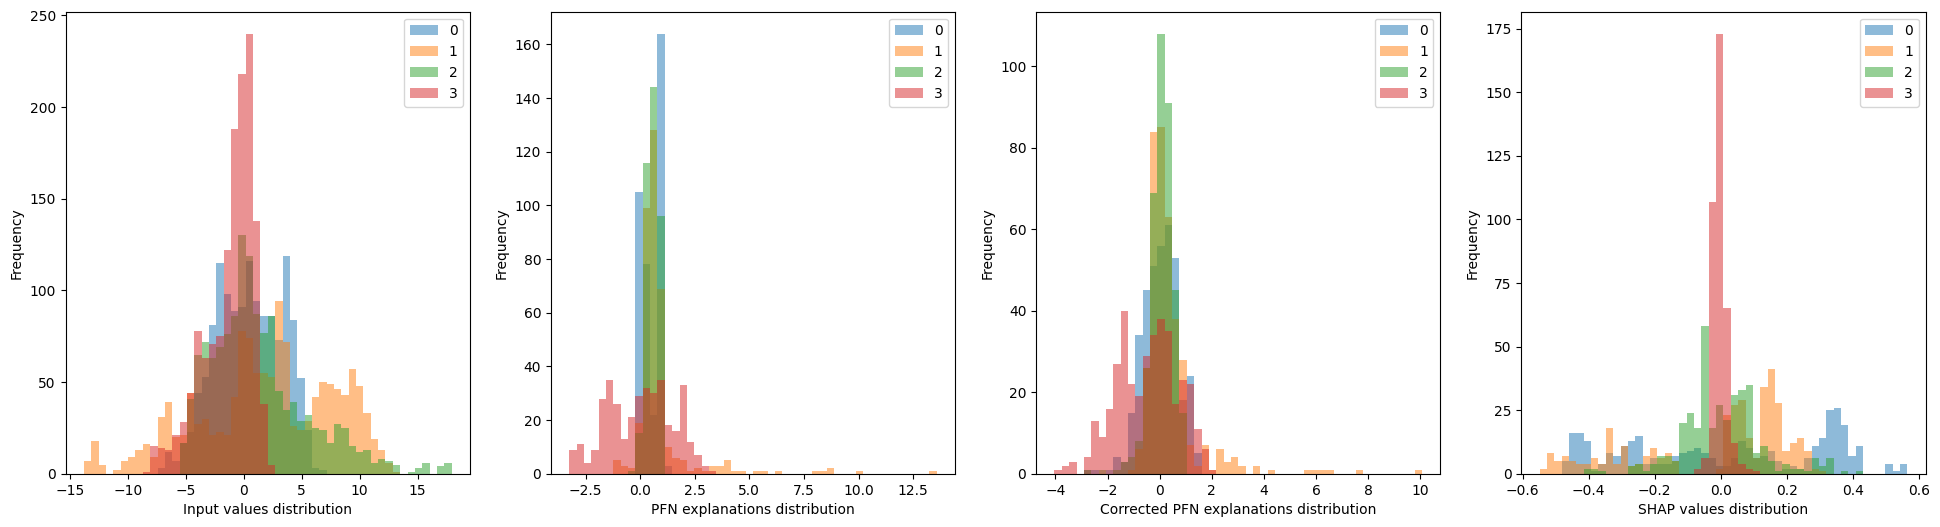

In [9]:
label_data = {
    "Input values": df.drop(columns="target"),
    "PFN explanations": df_explanations.drop(columns="target"),
    "Corrected PFN explanations": df_explanations_corrected.drop(columns="target"),
    "SHAP values": df_shap.drop(columns="target")
}

fig, axes = plt.subplots(nrows=1, ncols=len(label_data), figsize=(6 * len(label_data), 6))
for ax, (label, data) in zip(axes, label_data.items()):
    data.plot.hist(
        bins=50, 
        alpha=0.5, 
        ax=ax,
    )
    ax.set_xlabel(f"{label} distribution")

# Model save/loading

In [5]:
# save_path = "../explainerpfn_model.ckp"
# self.save_foundation_model(save_path)

In [6]:
# self = SingleFeatureExplainerPFN(feature_idx=1, model_path="../explainerpfn_model.ckp", random_state=42)
# self.fit(X_test, y_test)

# Model finetuning

In [ ]:
# We want to finetune the model by passing X and y as inputs, while SHAP values are used as the target.

import torch.optim as optim
import numpy as np
from tqdm.auto import tqdm

# Create a new ExplainerPFN for the feature we want to finetune
xai = ExplainerPFN(model_path="../../test_explainerpfn_model.ckp", random_state=42)
xai.fit(X_train, y_train)

# # Set model to training mode and disable inference mode to allow backprop
# xai.executor_.use_torch_inference_mode(False)
# 
# # Extract the model and move it to the target device
# device = xai.device_
# model = xai.model_
# xai.model_.cache_trainset_representation = False  # Disable caching to allow finetuning
# xai.model_.train()

# Setup optimizer - using Adam with a relatively small learning rate
# NOTE: Probably use lr=1e-5
optimizer = optim.Adam(xai.model_.parameters(), lr=1e-4)

# Training parameters
num_epochs = 100
batch_size = len(X_train)
batch_size = batch_size if len(X_train) > batch_size else len(X_train)

# Training loop
losses = []
for epoch in tqdm(range(num_epochs), desc="Finetuning epochs"):
    # Shuffle indices for each epoch
    indices = np.random.permutation(len(X_train))
    epoch_losses = []
    
    # Batch training
    for start_idx in range(0, len(X_train), batch_size):
        batch_indices = indices[start_idx:start_idx + batch_size]
        
        # Get batch data
        X_batch = X_train[batch_indices]
        y_batch = y_train[batch_indices]
        shap_batch = X_train_shap[batch_indices]
        
        loss = xai.finetune(optimizer, X_batch, y_batch, shap_batch)
        
        # Record loss
        epoch_losses.append(loss)
    
    # Average loss for the epoch
    avg_loss = sum(epoch_losses) / len(epoch_losses)
    losses.append(avg_loss)
    
    # if epoch % 5 == 0:
    #     print(f"Epoch {epoch}, Loss: {avg_loss:.6f}")
    print(f"Epoch {epoch}, Loss: {avg_loss:.6f}")

# Plot the training loss curve
plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

# # Compare original vs finetuned model on test data
# original_preds = model.predict(X_test, y_test)
# finetuned_preds = finetuned_model.predict(X_test, y_test)
# 
# # Calculate correlation with SHAP values
# original_corr = np.corrcoef(original_preds, df_shap_test[X_test.columns[feature_to_tune]])[0, 1]
# finetuned_corr = np.corrcoef(finetuned_preds, df_shap_test[X_test.columns[feature_to_tune]])[0, 1]
# 
# print(f"Correlation with SHAP before finetuning: {original_corr:.4f}")
# print(f"Correlation with SHAP after finetuning: {finetuned_corr:.4f}")

# Save the finetuned model if desired
xai.save_foundation_model("../../test_explainerpfn_model.ckp")

Finetuning epochs:   0%|          | 0/100 [00:00<?, ?it/s]

TypeError: ExplainerPFN.finetune() takes 4 positional arguments but 5 were given

In [19]:
xai.executor_.inference_mode

False

# Estimating feature importance after model training

In [5]:
xai = ExplainerPFN(model_path="../../test_explainerpfn_model.ckp", random_state=42)
xai.fit(X_train, y_train)
explanations = xai.predict(X_test, y_test)

In [ ]:
# Apply correction to ensure additivity
eps = (y_test - xai.base_value_) / explanations.sum(axis=1)
explanations_corrected = explanations * eps.reshape(-1, 1)

# This approach can lead to outliers, so we clip them
threshold = y_test.std() * 3
explanations_corrected = np.clip(explanations_corrected, a_min=-threshold, a_max=threshold)

In [19]:
correlations = {}

# Correlation between input values and the predicted target
correlations["input_values_vs_target"] = df.corr()["target"]

# Correlation between shapley values and the predicted target
correlations["shap_vs_target"] = df_shap.corr()["target"]

# Correlation between PFN explanations and the predicted target
df_explanations = pd.DataFrame(explanations.astype(float), columns=df_train.columns.drop("target"))
df_explanations["target"] = y_test
correlations["pfn_exp_vs_target"] = df_explanations.corr()["target"]

# Correlation between the corrected PFN explanations and the predicted target
df_explanations_corrected = pd.DataFrame(explanations_corrected.astype(float), columns=df_train.columns.drop("target"))
df_explanations_corrected["target"] = y_test
correlations["pfn_exp_corr_vs_target"] = df_explanations_corrected.corr()["target"]

# Correlation between PFN explanations and SHAP values
correlations["pfn_exp_vs_shap"] = pd.Series(
    [
        np.corrcoef(df_explanations.loc[:, i], df_shap.loc[:, i])[0, 1] 
        for i in df_explanations.columns
    ],
    index=df_explanations.columns
)

# Correlation between corrected PFN explanations and SHAP values
correlations["pfn_exp_corr_vs_shap"] = pd.Series(
    [
        np.corrcoef(df_explanations_corrected.loc[:, i], df_shap.loc[:, i])[0, 1] 
        for i in df_explanations_corrected.columns
    ],
    index=df_explanations_corrected.columns
)

pd.DataFrame(correlations)

,input_values_vs_target,shap_vs_target,pfn_exp_vs_target,pfn_exp_corr_vs_target,pfn_exp_vs_shap,pfn_exp_corr_vs_shap
0,-0.724843,0.859453,0.623116,0.135956,0.525183,0.142723
1,-0.444688,0.709327,-0.278622,0.354346,-0.062547,0.185454
2,0.155883,0.262016,-0.165090,0.337346,0.342341,0.130464
3,-0.023424,0.558550,0.484459,-0.052221,0.546799,-0.060234
target,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


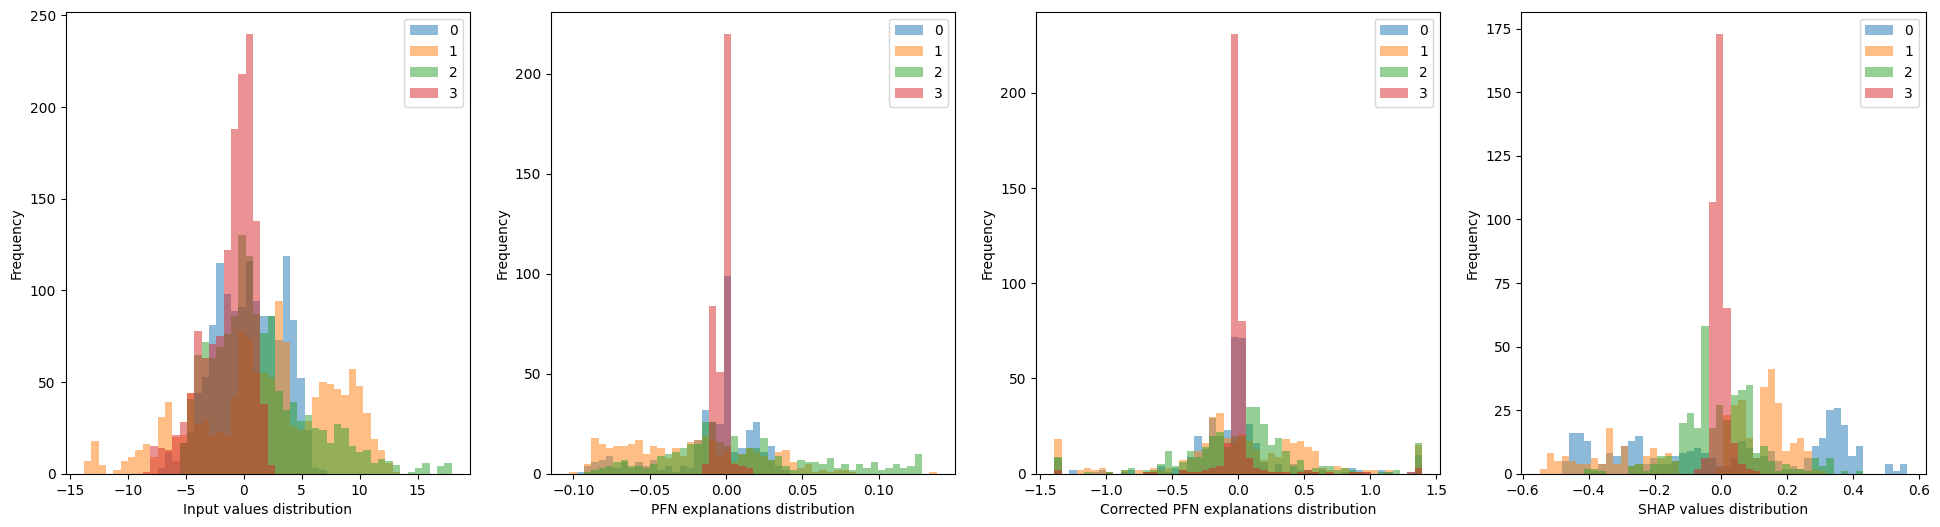

In [20]:
label_data = {
    "Input values": df.drop(columns="target"),
    "PFN explanations": df_explanations.drop(columns="target"),
    "Corrected PFN explanations": df_explanations_corrected.drop(columns="target"),
    "SHAP values": df_shap.drop(columns="target")
}

fig, axes = plt.subplots(nrows=1, ncols=len(label_data), figsize=(6 * len(label_data), 6))
for ax, (label, data) in zip(axes, label_data.items()):
    data.plot.hist(
        bins=50, 
        alpha=0.5, 
        ax=ax,
    )
    ax.set_xlabel(f"{label} distribution")